In [ ]:
from scipy.io import loadmat

# SpikeInterface
from probeinterface import Probe
import spikeinterface as si
import spikeinterface.sorters as ss

import sys
_rcp_root = r'e:\NHP_Cerebellum_Project_2025_RCP_Analysis_Git\RCP_analysis'
if _rcp_root not in sys.path:
    sys.path.insert(0, _rcp_root)

import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *

"""
    This script preprocesses the Intan data.
    Input:
        .rhs files from Intan
    Output:
        Checkpoint after preprocessing
        Checkpoint after thresholding and calculating MUA peak locations and firing rate
"""

# ---------- Config ----------
# Base paths from config_loading
GEOM_PATH = rcp.resolve_probe_geom_path(PARAMS, REPO_ROOT, session_key=None)

# Intan streams
NPRW_CFG = PARAMS.probes.get("NPRW")
INTAN_STREAM = NPRW_CFG.get("neural_data_stream")
STIM_STREAM = NPRW_CFG.get("stim_data_stream") # "Stim channel"
AUX_STREAM = NPRW_CFG.get("aux_stream")
IR_STREAM = NPRW_CFG.get("ir_stream")
PROCESS_ONLY = PARAMS.preprocessing.get("process_only")  # list of BR indices to process; empty = all, need to map from BR indices to Intan indices using METADATA

# Local reference params, both floats
RADII = (PARAMS.probes.get("NPRW").get("local_radius_inner"), PARAMS.probes.get("NPRW").get("local_radius_outer"))
RATES = PARAMS.NPRW_rate_est
BIN_MS     = RATES.get("bin_ms")
SIGMA_MS   = RATES.get("sigma_ms")
THRESH     = RATES.get("detect_threshold")
PEAK_SIGN  = RATES.get("peak_sign")
ARTRMV_MS_BEFORE = float(RATES.get("remove_ms_before", 20.0))
ARTRMV_TAIL_MS   = float(RATES.get("remove_tail_ms_after", 20.0))

NPRW_CKPT_OUT = OUT_BASE / "checkpoints" / "NPRW"
NPRW_SORT_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / "NPRW" / "folder_KS4"
NPRW_SORT_ANALYZE_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / "NPRW" / "my_sorting_analyzer"
        
global_job_kwargs = dict(n_jobs=PARAMS.parallel_jobs, chunk_duration=PARAMS.chunk)
si.set_global_job_kwargs(**global_job_kwargs)

# 1) Load geometry & mapping
mat_probe = loadmat(Path(GEOM_PATH))
intan_geom = {}
intan_geom["x"] = mat_probe["xcoords"].ravel()
intan_geom["y"] = mat_probe["ycoords"].ravel()
assert intan_geom["x"].size == intan_geom["y"].size, "x/y must have same length"
if "chanMap0ind" in mat_probe: # 0-based device mapping if present
    intan_probe_mapping = intan_geom["device_index_0based"] = mat_probe["chanMap0ind"].ravel()
else:
    raise ValueError("No 0-based chanmap in .mat geometry file.")
if intan_probe_mapping.size != intan_geom["x"].size:
    raise ValueError("device_index_0based length != #contacts")

# Build ProbeInterface Probe
nprw_probe = Probe(ndim=2)
nprw_probe.set_contacts(positions=np.c_[intan_geom["x"], intan_geom["y"]], shapes="square", shape_params={"width": 12.0})
nprw_probe.set_device_channel_indices(intan_probe_mapping) # Apply mapping


In [11]:
INDEX = 0

# 2) Find sessions and load data from each Intan folder
sess_folders = rcp.list_intan_sessions(INTAN_ROOT)
print(f"Found Intan sessions: {len(sess_folders)}")

nprw_pp_folders = sorted(NPRW_CKPT_OUT.glob("pp_*"))
nprw_pp_folder = nprw_pp_folders[INDEX]
print(nprw_pp_folder)

nprw_peaks_folders = sorted(NPRW_CKPT_OUT.glob("rates__*.npz"))
nprw_peaks_folder = nprw_peaks_folders[INDEX]
print(nprw_peaks_folder)

# for sess in sess_folders[:]: # Can tweak here to isolate sessions
rec_nprw = si.load(nprw_pp_folder)

def _parse_SI_peaks(peaks) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times = {}
    peak_amp = {}
    for i in np.unique(peaks['channel_index']):
        peak_ch_times = peaks['sample_index'][peaks['channel_index'] == i]
        peak_ch_amp = peaks['amplitude'][peaks['channel_index'] == i]
        peak_times[i] = peak_ch_times
        peak_amp[i] = peak_ch_amp
    return peak_times, peak_amp

nprw_peaks_si_obj = np.load(nprw_peaks_folder, allow_pickle=True)
nprw_peak_samps, nprw_peak_amps = _parse_SI_peaks(nprw_peaks_si_obj['peaks'])
nprw_peak_ms   = {k: (v / 30000)   * 1000.0 for k, v in nprw_peak_samps.items()}

Found Intan sessions: 31
\\cullenstor.win.ad.jhu.edu\data\Current Project Databases - NHP\2025 Cerebellum prosthesis\Nike\20260116_NRR_RW012\results\checkpoints\NPRW\pp_local_30_150__interp_NRR_RW012_260116_131117
\\cullenstor.win.ad.jhu.edu\data\Current Project Databases - NHP\2025 Cerebellum prosthesis\Nike\20260116_NRR_RW012\results\checkpoints\NPRW\rates__NRR_RW012_260116_131117__bin20ms_sigma20ms.npz


array([  4331.43333333,  10249.26666667,  15232.9       ,  20705.33333333,
        25920.63333333,  31043.2       ,  36743.        ,  41809.76666667,
        48290.16666667,  54234.83333333,  62165.36666667,  67733.3       ,
        72612.73333333,  78271.26666667,  84165.26666667,  90130.8       ,
        94766.9       , 100221.4       , 106371.4       ])

In [ ]:

sorting_KS4 = ss.run_sorter(sorter_name="kilosort4", recording=rec_nprw, folder=NPRW_SORT_CKPT_OUT)

100%|██████████| 1/1 [00:02<00:00,  2.85s/it]


In [ ]:
job_kwargs = dict(n_jobs=-1, progress_bar=True, chunk_duration="1s")

sorting_analyzer = si.create_sorting_analyzer(sorting_KS4, rec_nprw,
                                              format="binary_folder", folder=NPRW_SORT_ANALYZE_CKPT_OUT,
                                              **job_kwargs)
sorting_analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=500)
sorting_analyzer.compute("waveforms", **job_kwargs)
sorting_analyzer.compute("templates", **job_kwargs)
sorting_analyzer.compute("noise_levels")
sorting_analyzer.compute("unit_locations", method="monopolar_triangulation")
sorting_analyzer.compute("isi_histograms")
sorting_analyzer.compute("correlograms", window_ms=100, bin_ms=5.)
sorting_analyzer.compute("principal_components", n_components=3, mode='by_channel_global', whiten=True, **job_kwargs)
sorting_analyzer.compute("quality_metrics", metric_names=["snr", "firing_rate"])
sorting_analyzer.compute("template_similarity")
sorting_analyzer.compute("spike_amplitudes", **job_kwargs)
sorting_analyzer.get_saved_extension_names

PosixPath('/home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260202_NRR_RW015/results/checkpoints/sorting_results/NPRW/folder_KS4')

In [12]:
nprw_peaks_si_obj['ir_ms'].shape

(0,)

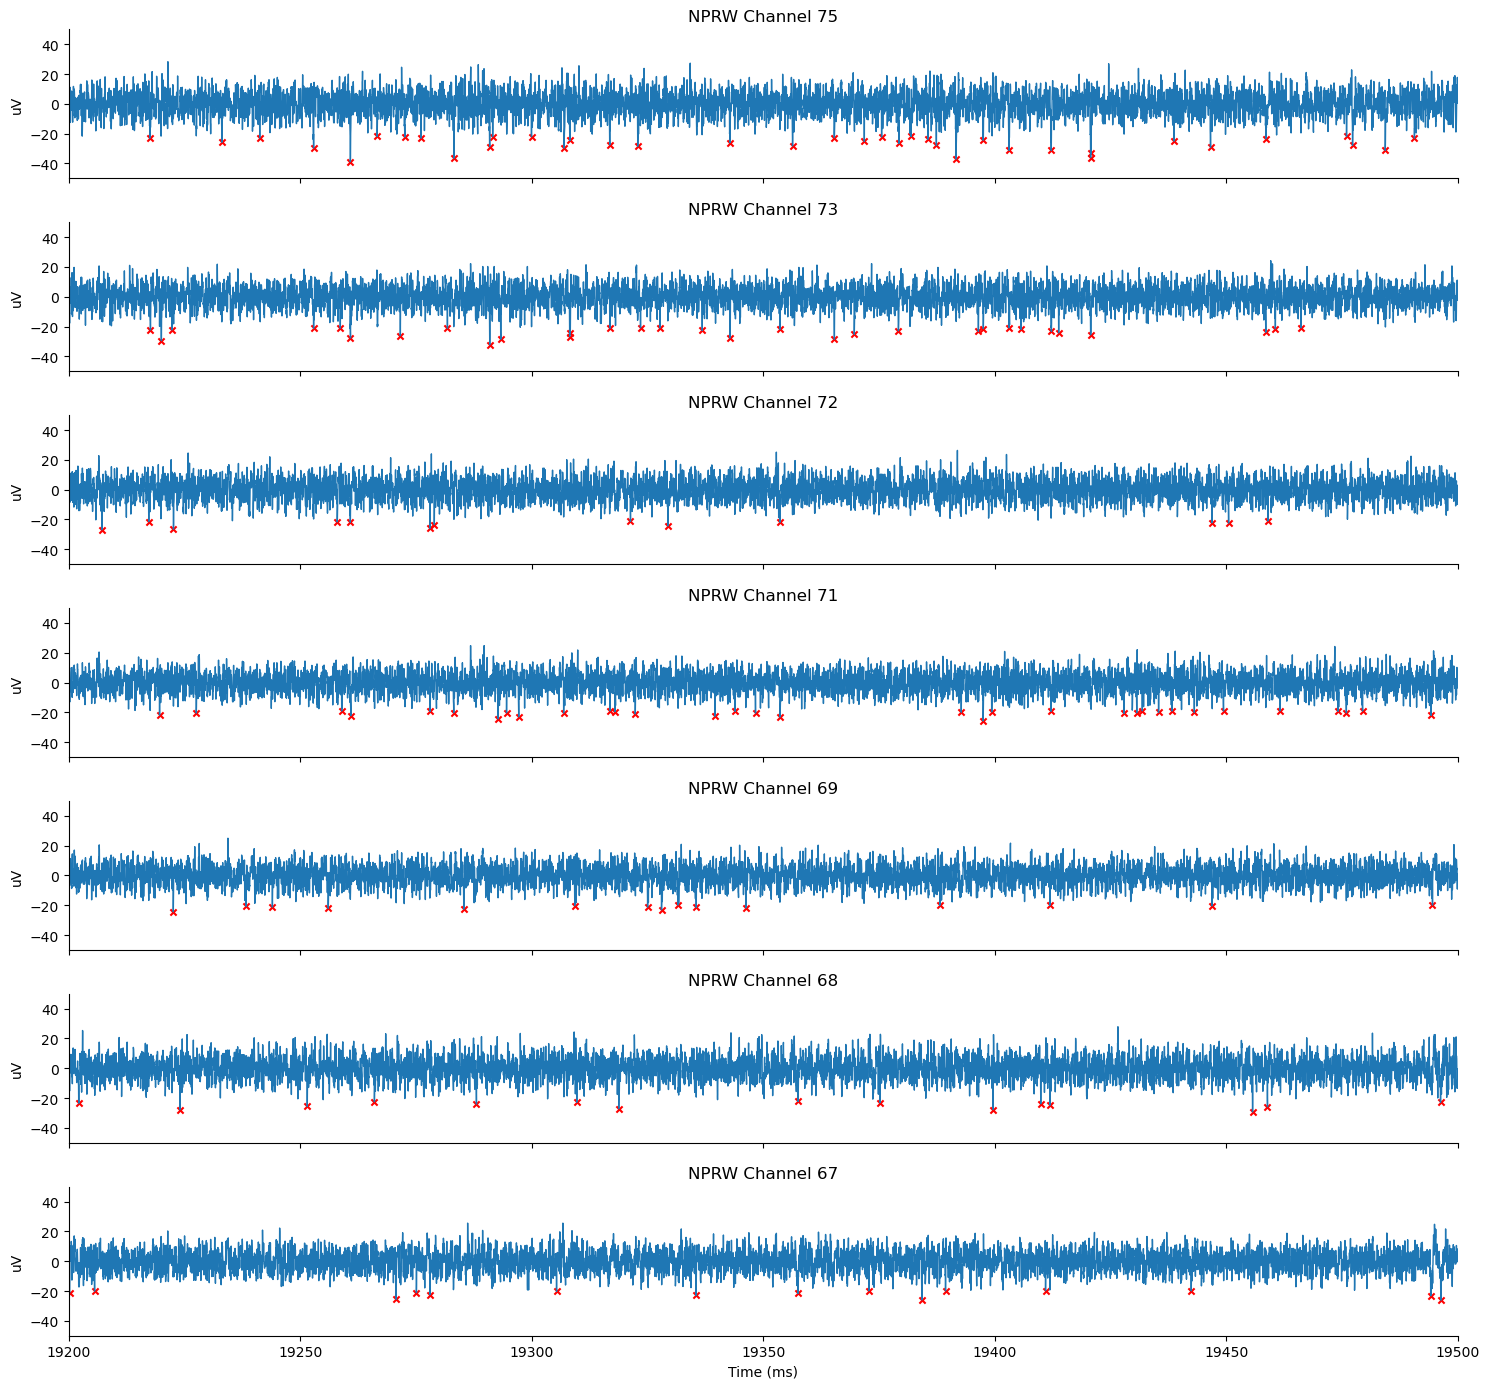

In [13]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

channels = [66, 67, 68, 70, 71, 72, 74] #[9, 10, 11, 31, 32, 33]

T0_MS = 19200 # 3948, 8754, 12998, 18264, 22590, 45460, 50684, 55660, 60708, 65530, 70176, 76038
T1_MS = T0_MS + 300
PLOT_SHIFT = 3

fs = fs_nprw = float(rec_nprw.get_sampling_frequency())
rec = rec_nprw

i0 = int(T0_MS * fs / 1000.0)
i1 = int(T1_MS * fs / 1000.0)

fig, axes = plt.subplots(len(channels), 1, figsize=(15, 3*len(channels)/1.5), sharex=True)

if len(channels) == 1:
    axes = [axes]

for ax, CH in zip(axes, channels[::-1]):

    ch_id = rec.get_channel_ids()[CH]

    # Raw trace
    y = rec.get_traces(
        start_frame=i0,
        end_frame=i1,
        channel_ids=[ch_id],
        return_in_uV=True
    ).squeeze()

    t = (np.arange(i0, i1) / fs) * 1000.0

    # Peak samples
    pk_s = np.asarray(
        nprw_peak_samps.get(CH, nprw_peak_samps.get(np.int64(CH), [])),
        dtype=np.int64
    )

    # Keep peaks inside window
    m = (pk_s >= i0) & (pk_s < i1)
    pk_s_w = pk_s[m]

    # Convert to window-relative indices
    pk_idx = (pk_s_w - i0).astype(int)

    # Convert to ms
    pk_ms_w = (pk_s_w / fs) * 1000.0

    # Sample amplitude directly from raw trace
    pk_y = y[pk_idx + PLOT_SHIFT]

    # Plot
    ax.plot(t, y, lw=1)

    if pk_ms_w.size:
        ax.scatter(
            pk_ms_w+PLOT_SHIFT/30,
            pk_y,
            s=20,
            marker="x",
            color="red"
        )

    ax.set_xlim(T0_MS, T1_MS)
    ax.set_ylim(-50, 50)
    ax.set_ylabel("uV")
    ax.set_title(f"NPRW Channel {CH+1}")
    ax.spines[["right", "top"]].set_visible(False)

axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

In [15]:
sorting_analyzer = si.load_sorting_analyzer(NPRW_SORT_ANALYZE_CKPT_OUT)

def peaks_ms_from_sorting(sorting, fs, segment_index=0):
    peaks_ms = {}
    for u in sorting.get_unit_ids():
        st_samp = sorting.get_unit_spike_train(u, segment_index=segment_index)
        peaks_ms[int(u)] = (st_samp.astype(np.float64) / fs) * 1000.0
    return peaks_ms

sorting = sorting_analyzer.sorting
rec = sorting_analyzer.recording
fs = rec.get_sampling_frequency()

peaks_ms = peaks_ms_from_sorting(sorting, fs, segment_index=0)

AssertionError: This folder does not exists \\cullenstor.win.ad.jhu.edu\data\Current Project Databases - NHP\2025 Cerebellum prosthesis\Nike\20260116_NRR_RW012\results\checkpoints\sorting_results\NPRW\my_sorting_analyzer

In [ ]:
import numpy as np

def peri_event_rates_from_peaks_ms(
    peaks_ms: dict[int, np.ndarray],
    event_times_ms: np.ndarray,
    win_ms=(-600.0, 600.0),
    bin_ms=20.0,
    sigma_ms=50.0,
):
    """
    Compute peri-event firing rates from spike times (ms).

    Args
    ----
    peaks_ms:
        dict {unit_id: spike_times_ms}
    event_times_ms:
        (n_events,) array of event times in ms (same timebase as peaks_ms)
    win_ms:
        (start_ms, end_ms) peri-event window relative to each event
    bin_ms:
        bin width in ms
    sigma_ms:
        Gaussian smoothing sigma in ms (0 disables smoothing)

    Returns
    -------
    rates_hz:
        (n_events, n_units, n_bins) smoothed peri-event rates in Hz
    centers_ms:
        (n_bins,) bin centers in ms relative to event
    unit_ids:
        list of unit_ids in the same order as axis=1
    """
    event_times_ms = np.asarray(event_times_ms, dtype=float).ravel()
    if event_times_ms.size == 0:
        raise ValueError("event_times_ms is empty.")

    unit_ids = sorted(peaks_ms.keys())
    n_units = len(unit_ids)
    if n_units == 0:
        raise ValueError("peaks_ms is empty.")

    w0, w1 = float(win_ms[0]), float(win_ms[1])
    if w1 <= w0:
        raise ValueError("win_ms must satisfy win_ms[1] > win_ms[0].")

    # Uniform bins across the full window
    edges_ms = np.arange(w0, w1 + bin_ms, bin_ms, dtype=float)
    centers_ms = edges_ms[:-1] + 0.5 * bin_ms
    n_bins = centers_ms.size

    # Allocate output
    rates = np.zeros((event_times_ms.size, n_units, n_bins), dtype=float)

    # Bin per event, per unit
    bin_s = bin_ms / 1000.0
    for ei, t0 in enumerate(event_times_ms):
        for ui, u in enumerate(unit_ids):
            st = np.asarray(peaks_ms[u], dtype=float)
            if st.size == 0:
                continue

            rel = st - t0  # ms relative to event
            # keep only spikes in window (saves time)
            rel = rel[(rel >= w0) & (rel < w1)]
            if rel.size == 0:
                continue

            counts, _ = np.histogram(rel, bins=edges_ms)
            rates[ei, ui] = counts / bin_s  # Hz

    # Gaussian smoothing along time axis (per event, per unit)
    if sigma_ms is not None and sigma_ms > 0:
        sigma_bins = sigma_ms / bin_ms
        r = int(np.ceil(4 * sigma_bins))
        k = np.arange(-r, r + 1, dtype=float)
        g = np.exp(-(k**2) / (2.0 * sigma_bins**2))
        g /= g.sum()

        # convolve along last axis
        # (simple and reliable; fast enough for typical n_events x n_units)
        sm = np.empty_like(rates)
        for ei in range(rates.shape[0]):
            for ui in range(rates.shape[1]):
                sm[ei, ui] = np.convolve(rates[ei, ui], g, mode="same")
        rates = sm

    return rates, centers_ms, unit_ids

In [ ]:
# FR estimate params
BIN_MS = 20.0
SIGMA_MS = 20.0

stim_times_ms = np.asarray(nprw_peaks_si_obj["ir_ms"], float).ravel()
rates_hz, centers_ms, unit_ids = peri_event_rates_from_peaks_ms(
    peaks_ms=peaks_ms,
    event_times_ms=stim_times_ms,
    win_ms=(-600, 600),
    bin_ms=BIN_MS,
    sigma_ms=SIGMA_MS,
)

psth_hz = np.nanmean(rates_hz, axis=0)   # (n_units, n_bins)

In [ ]:
print("rates_hz:", rates_hz.shape)  # (n_events, n_units, n_bins)
print("psth_hz:", psth_hz.shape)    # (n_units, n_bins)
print("time window:", centers_ms[0], "to", centers_ms[-1], "ms")

rates_hz: (19, 54, 60)
psth_hz: (54, 60)
time window: -590.0 to 590.0 ms


In [ ]:
import numpy as np
# per-trial baseline mean/std per unit (events, units, 1)
mu  = np.nanmean(rates_hz[:, :, :], axis=2, keepdims=True)
sig = np.nanstd (rates_hz[:, :, :], axis=2, keepdims=True)
sig = np.clip(sig, 1e-6, None)

# trial-level z-score (events, units, bins)
rates_z = (rates_hz - mu) / sig

# average across trials/events -> PSTH z (units, bins)
psth_z = np.nanmean(rates_z, axis=0)

In [ ]:
peak_mask = (centers_ms >= -600) & (centers_ms <= 600)

X = psth_z[:, peak_mask]
t = centers_ms[peak_mask]

# Peak value and peak time (argmax) within the search window
X_finite = np.where(np.isfinite(X), X, -np.inf)
peak_idx = np.argmax(X_finite, axis=1)
peak_time_ms = t[peak_idx]
peak_val = np.max(X_finite, axis=1)

# Keep only neurons with a real response; rest go to bottom
z_thresh = 0.1  # tune (0.5–1.5 is common)
responsive = np.isfinite(peak_val) & (peak_val >= z_thresh)

order_resp = np.argsort(peak_time_ms[responsive])  # earliest first
order = np.concatenate([np.where(responsive)[0][order_resp],
                        np.where(~responsive)[0]])

psth_sorted = psth_z[order]

In [ ]:
psth_sorted

array([[-0.05203142,  0.13837261,  0.43993268, ..., -0.09481953,
        -0.09822042, -0.09832632],
       [-0.06131945, -0.0196211 ,  0.15776302, ..., -0.06139677,
        -0.06479766, -0.06490355],
       [-0.03945748, -0.03605659,  0.00315805, ..., -0.03956337,
        -0.03956337, -0.03956337],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(54, 60))

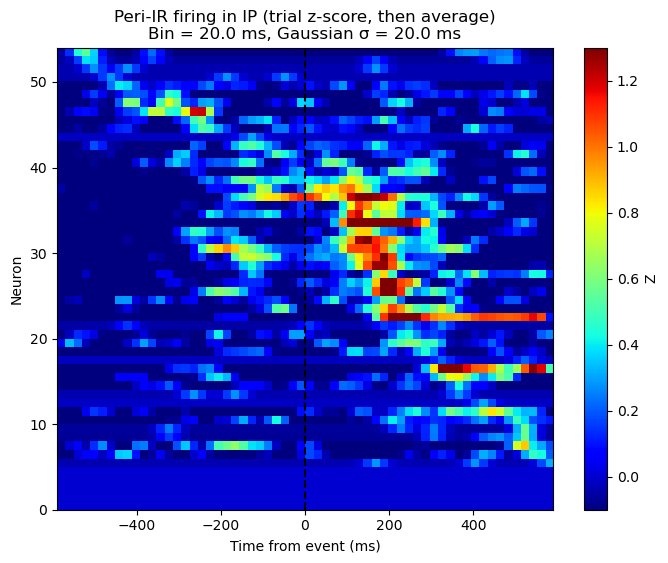

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(
    psth_sorted,
    aspect="auto",
    origin="upper",
    extent=[centers_ms[0], centers_ms[-1], 0, psth_z.shape[0]],
    cmap="jet",
    vmin=-0.1,
    vmax=1.3,
)
plt.axvline(0, linestyle="--", color="black")
plt.xlabel("Time from event (ms)")
plt.ylabel("Neuron")
plt.title(
    f"Peri-IR firing in IP (trial z-score, then average)\nBin = {BIN_MS} ms, Gaussian σ = {SIGMA_MS} ms"
)
plt.colorbar(label="Z")
plt.show()

In [ ]:
PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
FILE = 'peristim__NRR_RW015_260202_113304__BR_001_target_A.npz'
CONTROL_PERI_ROOT = PERI_ROOT / "control_reaches"
# Load control
control_dir = CONTROL_PERI_ROOT / 'target_A'
control_npz_path = control_dir / FILE
control_npz = np.load(control_npz_path, allow_pickle=True)

In [ ]:
control_npz['NPRW_med']

array([[-18.11419797,  -3.5768309 ,  10.10500541, ...,  -3.77295945,
         -3.56402697,   3.3940444 ],
       [  7.47811545,   6.17296831,  -3.39466087, ...,   2.91046526,
         11.26074369,  27.06207431],
       [  3.92694216,  -7.68044032,  -8.72088614, ...,  15.93264922,
         13.18131913,  18.91508238],
       ...,
       [ -3.80848601,  -3.54198319,  -6.96355167, ...,  19.2126873 ,
         15.31128183,  35.17545816],
       [  6.05970308,  -4.11296478,  -7.47757366, ...,  42.85850405,
         26.99067078,  22.53978506],
       [  6.20058661,   1.99417014,  -4.15656075, ...,  36.78027786,
         23.44778323,  18.34638189]], shape=(128, 60))

In [ ]:
rates_ch_hz = control_npz['NPRW_rates_hz']
psth_ch_hz = np.nanmean(rates_ch_hz, axis=0)   # (n_ch, n_bins)
import numpy as np
# per-trial baseline mean/std per unit (events, units, 1)
mu  = np.nanmean(rates_ch_hz[:, :, :], axis=2, keepdims=True)
sig = np.nanstd (rates_ch_hz[:, :, :], axis=2, keepdims=True)
sig = np.clip(sig, 1e-6, None)
rates_ch_z = (rates_ch_hz - mu) / sig
psth_ch_z = np.nanmean(rates_ch_z, axis=0)

In [ ]:
peak_mask = (centers_ms >= -600) & (centers_ms <= 600)

X = psth_ch_z[:, peak_mask]
t = centers_ms[peak_mask]

# Peak value and peak time (argmax) within the search window
X_finite = np.where(np.isfinite(X), X, -np.inf)
peak_idx = np.argmax(X_finite, axis=1)
peak_time_ms = t[peak_idx]
peak_val = np.max(X_finite, axis=1)

# Keep only neurons with a real response; rest go to bottom
z_thresh = 0.1  # tune (0.5–1.5 is common)
responsive = np.isfinite(peak_val) & (peak_val >= z_thresh)

order_resp = np.argsort(peak_time_ms[responsive])  # earliest first
order = np.concatenate([np.where(responsive)[0][order_resp],
                        np.where(~responsive)[0]])

psth_sorted = psth_z[order]